In [16]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def show_tree(fname):
    with h5py.File(fname, "r") as f:
        f.visititems(lambda name, obj: print(name, obj.shape if hasattr(obj, "shape") else ""))

def read_temp_data(fname):
    out = {}
    with h5py.File(fname, "r") as f:
        g = f["temp_data"] if "temp_data" in f else f["observables"]
        for key in g.keys():
            if isinstance(g[key], h5py.Dataset):
                out[key] = g[key][()]
    return out

In [18]:
for fname in ["single_output.h5", "anneal_output.h5", "pt_output.h5"]:
    f = f"build/"+fname
    print("\n", f)
    show_tree(f)


 build/single_output.h5
metadata 
metadata/model 
metadata/run 
observables 
observables/Cv 
observables/E 
observables/E/bin_counts (20,)
observables/E/bin_sums (20,)
observables/E2 
observables/E2/bin_counts (20,)
observables/E2/bin_sums (20,)
observables/M 
observables/M/bin_counts (20,)
observables/M/bin_sums (20,)
observables/M2 
observables/M2/bin_counts (20,)
observables/M2/bin_sums (20,)
observables/absM 
observables/absM/bin_counts (20,)
observables/absM/bin_sums (20,)
observables/chi_abs 

 build/anneal_output.h5
metadata 
metadata/run 
temp_data 
temp_data/Cv (64,)
temp_data/Cv_err (64,)
temp_data/E (64,)
temp_data/E2 (64,)
temp_data/E2_err (64,)
temp_data/E_err (64,)
temp_data/M (64,)
temp_data/M2 (64,)
temp_data/M2_err (64,)
temp_data/M_err (64,)
temp_data/T (64,)
temp_data/absM (64,)
temp_data/absM_err (64,)
temp_data/chi_abs (64,)
temp_data/chi_abs_err (64,)

 build/pt_output.h5
metadata 
metadata/run 
pt 
pt/swap_accepts (15,)
pt/swap_attempts (15,)
temp_data 
temp_dat

Single temp (debuging mainly)

In [21]:
single = read_temp_data("build/single_output.h5")

for k, v in single.items():
    if np.ndim(v) == 0:
        print(f"{k:12s} = {v}")
    else:
        print(f"{k:12s} = {v}")

Annealing

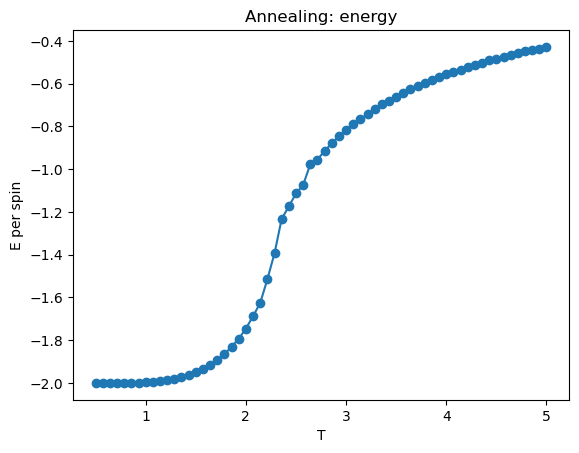

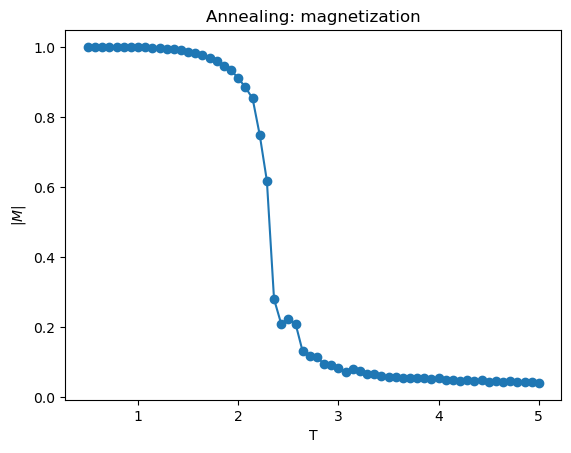

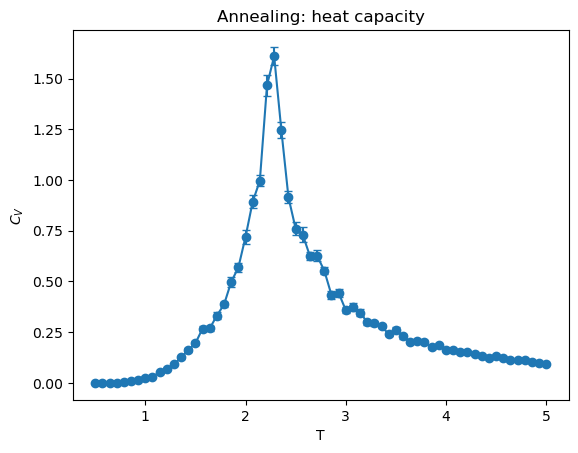

In [25]:
anneal = read_temp_data("build/anneal_output.h5")

T = anneal["T"]

fig, ax = plt.subplots()
ax.errorbar(T, anneal["E"], yerr=anneal.get("E_err", None), marker="o", capsize=3)
ax.set_xlabel("T")
ax.set_ylabel("E per spin")
ax.set_title("Annealing: energy")

plt.show()

fig, ax = plt.subplots()
ax.errorbar(T, anneal["absM"], yerr=anneal.get("absM_err", None), marker="o", capsize=3)
ax.set_xlabel("T")
ax.set_ylabel(r"$|M|$")
ax.set_title("Annealing: magnetization")

plt.show()

fig, ax = plt.subplots()
ax.errorbar(T, anneal["Cv"], yerr=anneal.get("Cv_err", None), marker="o", capsize=3)
ax.set_xlabel("T")
ax.set_ylabel(r"$C_V$")
ax.set_title("Annealing: heat capacity")

plt.show()

Parallel tempering

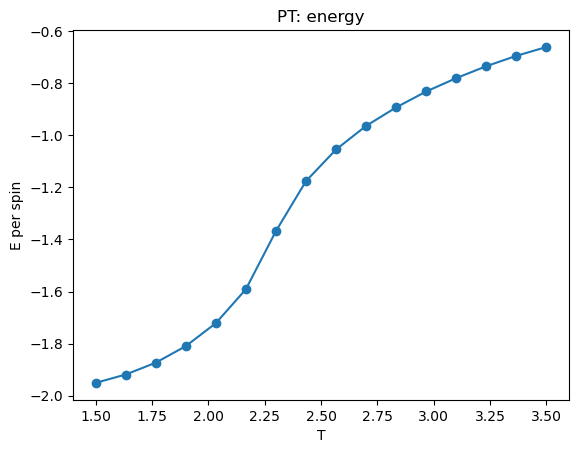

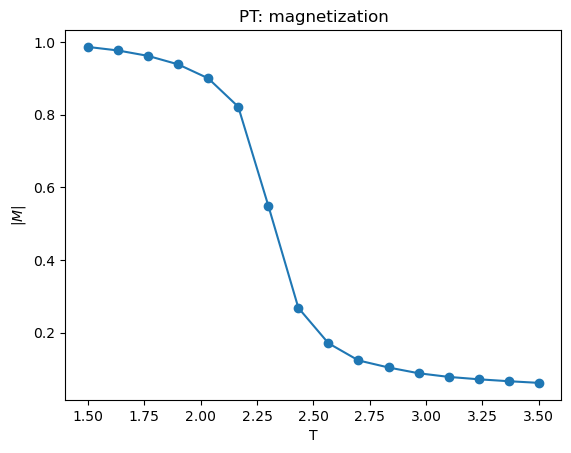

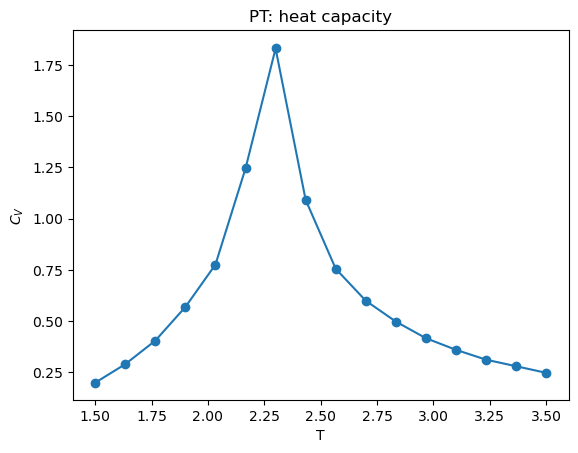

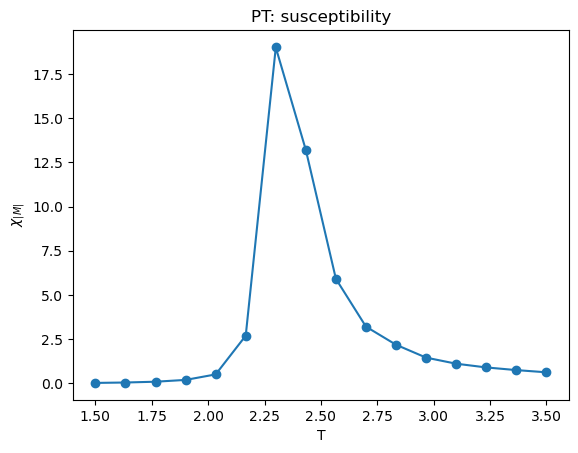

In [26]:
pt = read_temp_data("build/pt_output.h5")

T = pt["T"]

fig, ax = plt.subplots()
ax.errorbar(T, pt["E"], yerr=pt.get("E_err", None), marker="o", capsize=3)
ax.set_xlabel("T")
ax.set_ylabel("E per spin")
ax.set_title("PT: energy")
plt.show()

fig, ax = plt.subplots()
ax.errorbar(T, pt["absM"], yerr=pt.get("absM_err", None), marker="o", capsize=3)
ax.set_xlabel("T")
ax.set_ylabel(r"$|M|$")
ax.set_title("PT: magnetization")
plt.show()

fig, ax = plt.subplots()
ax.errorbar(T, pt["Cv"], yerr=pt.get("Cv_err", None), marker="o", capsize=3)
ax.set_xlabel("T")
ax.set_ylabel(r"$C_V$")
ax.set_title("PT: heat capacity")
plt.show()

fig, ax = plt.subplots()
ax.errorbar(T, pt["chi_abs"], yerr=pt.get("chi_abs_err", None), marker="o", capsize=3)
ax.set_xlabel("T")
ax.set_ylabel(r"$\chi_{|M|}$")
ax.set_title("PT: susceptibility")
plt.show()

Compare annealing vs parallel temping

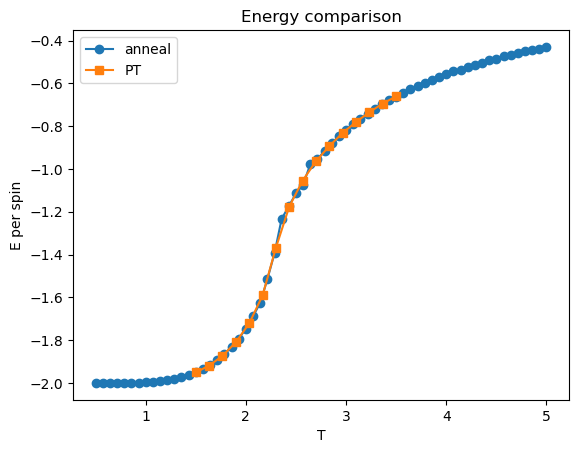

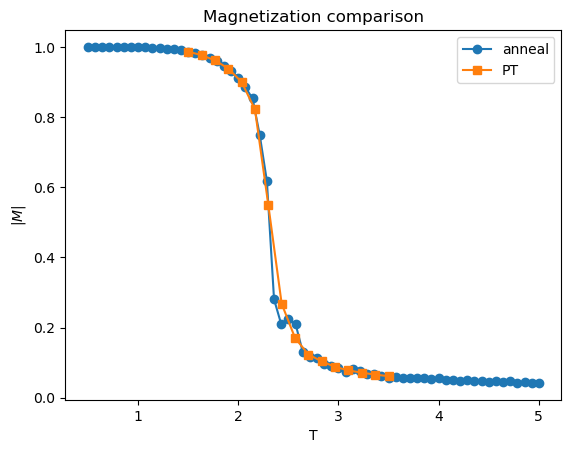

In [27]:
fig, ax = plt.subplots()
ax.plot(anneal["T"], anneal["E"], marker="o", label="anneal")
ax.plot(pt["T"], pt["E"], marker="s", label="PT")
ax.set_xlabel("T")
ax.set_ylabel("E per spin")
ax.set_title("Energy comparison")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(anneal["T"], anneal["absM"], marker="o", label="anneal")
ax.plot(pt["T"], pt["absM"], marker="s", label="PT")
ax.set_xlabel("T")
ax.set_ylabel(r"$|M|$")
ax.set_title("Magnetization comparison")
ax.legend()
plt.show()